# 01 — สำรวจและตรวจคุณภาพข้อมูล

**ข้อมูล:** Procure-To-Payment (P2P) Object-centric Event Log in OCEL 2.0 Standard (Zenodo record 8412920, CC BY 4.0)
**สำคัญ:** เป็นข้อมูล *จำลอง* ที่สร้างตามโครงสร้างธุรกรรม SAP ไม่ใช่ log จริงของบริษัท

เป้าหมายของ notebook นี้
1. นับขนาดข้อมูล: events, objects, activities, ช่วงเวลา
2. ดูโครงสร้าง object-centric: แต่ละ activity แตะ object ประเภทไหน และ object เชื่อมกันอย่างไร
3. ตรวจคุณภาพ: ค่าว่าง, เวลาซ้ำ, object ที่ไม่มี event, ลำดับเวลาผิดปกติ, case ที่ไม่จบ
4. ตัดสินใจเรื่อง *case notion* (จะใช้อะไรเป็น "1 case") สำหรับช่วงถัดไป

ตัวเลขทุกตัวที่ใช้ในรายงานถูกเขียนลง `results/01_explore.json` ในเซลล์สุดท้าย

In [1]:
import sys, json, hashlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
import p2p_data as d

pd.set_option('display.width', 160)
R = {}   # ตัวเลขทั้งหมดที่จะบันทึก
FIG = Path.cwd().parent / 'figures'
R['file_md5'] = hashlib.md5(d.DATA.read_bytes()).hexdigest()
con = d.connect()
R['file_md5']

'1a4238260019939239488b0b4befb515'

## 1. ตารางในไฟล์ SQLite
OCEL 2.0 เก็บ event, object และความสัมพันธ์แยกตาราง และเก็บ attribute แยกตามประเภท

In [2]:
tables = pd.read_sql("select name from sqlite_master where type='table'", con).name
table_rows = {t: con.execute(f'select count(*) from "{t}"').fetchone()[0] for t in tables}
pd.Series(table_rows, name='rows').to_frame()

,rows
event,14671
event_map_type,10
object,9543
object_object,20402
object_map_type,7
event_object,35927
event_ApprovePurchaseOrder,1598
event_ApprovePurchaseRequisition,607
event_CreateGoodsReceipt,4042
event_CreateInvoiceReceipt,1941


## 2. ขนาดข้อมูลโดยรวม

In [3]:
ev  = d.load_events(con)
obj = d.load_objects(con)
eo  = d.load_event_object(con)
oo  = d.load_object_object(con)

R['n_events'] = len(ev)
R['n_event_ids_unique'] = int(ev.ocel_id.nunique())
R['n_objects'] = len(obj)
R['n_activities'] = int(ev.activity.nunique())
R['n_object_types'] = int(obj.ocel_type.nunique())
R['n_event_object_links'] = len(eo)
R['n_object_object_links'] = len(oo)
R['time_min'] = str(ev.ocel_time.min()); R['time_max'] = str(ev.ocel_time.max())
R['time_span_days'] = int((ev.ocel_time.max() - ev.ocel_time.min()).days)
{k: R[k] for k in ['n_events','n_objects','n_activities','n_object_types','n_event_object_links','n_object_object_links','time_min','time_max','time_span_days']}

{'n_events': 14671,
 'n_objects': 9543,
 'n_activities': 10,
 'n_object_types': 7,
 'n_event_object_links': 35927,
 'n_object_object_links': 20402,
 'time_min': '2022-04-01 09:26:00+00:00',
 'time_max': '2024-10-31 20:28:00+00:00',
 'time_span_days': 944}

In [4]:
act = ev.activity.value_counts().rename('events')
R['events_per_activity'] = act.to_dict()
act.to_frame()

,events
activity,
Create Goods Receipt,4042
Create Invoice Receipt,1941
Perform Two-Way Match,1941
Approve Purchase Order,1598
Create Purchase Order,1598
Execute Payment,1166
Create Request for Quotation,927
Create Purchase Requisition,729
Approve Purchase Requisition,607


In [5]:
ot = obj.ocel_type.value_counts().rename('objects')
R['objects_per_type'] = ot.to_dict()
ot.to_frame()

,objects
ocel_type,
material,2296
goods receipt,1941
purchase_order,1598
invoice receipt,927
payment,927
purchase_requisition,927
quotation,927


In [6]:
res = ev.resource.value_counts(dropna=False).rename('events')
R['events_per_resource'] = res.to_dict()
R['lifecycle_values'] = ev.lifecycle.value_counts().to_dict()
res.to_frame()

,events
resource,
Finance/Account Department,5048
Warehouse Department,4042
Procurement Department,2525
Procurement Order Manager,1598
Manufacturing Department,851
Procurement Requisition Manager,607


## 3. โครงสร้าง object-centric
แต่ละ event อาจผูกกับ object หลายประเภทพร้อมกัน เช่น `Execute Payment` ผูกกับ payment, invoice, goods receipt และ purchase order
ตารางนี้นับจำนวน *ลิงก์* event→object แยกตาม activity × ประเภท object

In [7]:
x = eo.merge(ev[['ocel_id','activity']], left_on='ocel_event_id', right_on='ocel_id')
ct = pd.crosstab(x.activity, x.object_type)
ct

object_type,goods receipt,invoice receipt,material,payment,purchase_order,purchase_requisition,quotation
activity,,,,,,,
Approve Purchase Order,0,0,0,0,1598,0,1598
Approve Purchase Requisition,0,0,1499,0,0,607,0
Create Goods Receipt,4042,0,0,0,4042,0,0
Create Invoice Receipt,1941,1941,0,0,0,0,0
Create Purchase Order,0,0,0,0,1598,0,1598
Create Purchase Requisition,0,0,1807,0,0,729,0
Create Request for Quotation,0,0,0,0,0,927,927
Delegate Purchase Requisition Approval,0,0,308,0,0,122,0
Execute Payment,2437,1166,0,1166,1992,0,0


In [8]:
# ต่อ 1 event ผูกกับ object แต่ละประเภทกี่ตัว (ค่าเฉลี่ย / สูงสุด)
per_ev = x.groupby(['activity','ocel_event_id','object_type']).size().reset_index(name='n')
per_ev.groupby(['activity','object_type']).n.agg(['mean','max']).round(2)

mean  max
activity                               object_type                    
Approve Purchase Order                 purchase_order        1.00    1
                                       quotation             1.00    1
Approve Purchase Requisition           material              2.47    4
                                       purchase_requisition  1.00    1
Create Goods Receipt                   goods receipt         1.00    1
                                       purchase_order        1.00    1
Create Invoice Receipt                 goods receipt         1.00    1
                                       invoice receipt       1.00    1
Create Purchase Order                  purchase_order        1.00    1
                                       quotation             1.00    1
Create Purchase Requisition            material              2.48    4
                                       purchase_requisition  1.00    1
Create Request for Quotation           purchase_requisition  1.00    1
                                       quotation             1.00    1
Delegate Purchase Requisition Approval material              2.52    4
                                       purchase_requisition  1.00    1
Execute Payment                        goods receipt         2.09    4
                                       invoice receipt       1.00    1
                                       payment               1.00    1
                                       purchase_order        1.71    4
Perform Two-Way Match                  goods receipt         1.00    1
                                       invoice receipt       1.00    1

### ความสัมพันธ์ระหว่าง object (object-to-object)
ใช้ดูว่าเอกสารเชื่อมกันเป็นสายอย่างไร: ใบขอซื้อ (PR) → ใบเสนอราคา (quotation) → ใบสั่งซื้อ (PO) → ใบรับของ (GR) → ใบแจ้งหนี้ (IR) → การจ่ายเงิน (payment)

In [9]:
rel = oo.groupby(['source_type','target_type','ocel_qualifier']).agg(
    links=('ocel_source_id','size'),
    distinct_sources=('ocel_source_id','nunique'),
    distinct_targets=('ocel_target_id','nunique')).reset_index()
rel

,source_type,target_type,ocel_qualifier,links,distinct_sources,distinct_targets
0,goods receipt,invoice receipt,Invoice Receipt of Goods Receipt,927,927,927
1,goods receipt,material,Materials of Goods Receipt,700,526,700
2,goods receipt,payment,goods_receipt_pm,1941,1941,927
3,goods receipt,purchase_order,Good Receipts of Purchase Order,1941,1941,927
4,invoice receipt,payment,invoice_receipt_pm,927,927,927
5,purchase_order,invoice receipt,Invoice Receipts of Purchase Order,927,927,927
6,purchase_order,material,Materials of Purchase Order,2296,1598,2296
7,purchase_order,payment,order_pm,1598,1598,927
8,purchase_requisition,material,assigned_materials of PR,2296,927,2296
9,purchase_requisition,quotation,Quotation of PR,927,927,927


In [10]:
# ตรวจ cardinality ของสายเอกสารหลัก: ลูกแต่ละตัวมีพ่อได้กี่ตัว
def parents_per_child(src, tgt):
    r = oo[(oo.source_type==src)&(oo.target_type==tgt)]  # target_type เป็น NaN ถ้า dangling จึงถูกตัดออกอัตโนมัติ
    return r.groupby('ocel_target_id').ocel_source_id.nunique()

def children_per_parent(src, tgt):
    r = oo[(oo.source_type==src)&(oo.target_type==tgt)]
    return r.groupby('ocel_source_id').ocel_target_id.nunique()

chain = [('purchase_requisition','quotation'), ('quotation','purchase_order'),
         ('goods receipt','purchase_order'), ('goods receipt','invoice receipt'),
         ('invoice receipt','payment')]
card = []
for s,t in chain:
    p = parents_per_child(s,t); c = children_per_parent(s,t)
    card.append({'source':s,'target':t,'max_sources_per_target':int(p.max()),
                 'max_targets_per_source':int(c.max()),'mean_targets_per_source':round(c.mean(),2)})
card = pd.DataFrame(card); R['cardinality'] = card.to_dict('records'); card

,source,target,max_sources_per_target,max_targets_per_source,mean_targets_per_source
0,purchase_requisition,quotation,1,1,1.00
1,quotation,purchase_order,1,4,1.72
2,goods receipt,purchase_order,4,1,1.00
3,goods receipt,invoice receipt,1,1,1.00
4,invoice receipt,payment,1,1,1.00


### ลิงก์ที่ชี้ไปหา object ที่ไม่มีอยู่ (dangling reference)
ตรวจว่าปลายทางของลิงก์ object→object มีอยู่ในตาราง `object` จริงหรือไม่

In [11]:
oo['target_prefix'] = oo.ocel_target_id.str.split(':').str[0]
dang = oo.assign(dangling=oo.target_type.isna()).groupby(['source_type','target_prefix','ocel_qualifier']).dangling.agg(links='size', dangling='sum')
dang = dang[dang.dangling>0]
R['dangling_object_links_total'] = int(oo.target_type.isna().sum())
R['dangling_object_links'] = dang.reset_index().to_dict('records')
dang

,,,links,dangling
source_type,target_prefix,ocel_qualifier,,
goods receipt,invoice receipt,Invoice Receipt of Goods Receipt,1941,1014
purchase_order,invoice receipt,Invoice Receipts of Purchase Order,1941,1014


In [12]:
# ใช้ event_object (ที่ไม่มี dangling) ยืนยันความสัมพันธ์ GR <-> invoice:
# event Create Invoice Receipt ผูก GR 1 ใบกับ invoice 1 ใบ
ci = x[x.activity=='Create Invoice Receipt'].pivot_table(index='ocel_event_id', columns='object_type', values='ocel_object_id', aggfunc='first')
gr_per_ir_ev = ci.groupby('invoice receipt')['goods receipt'].nunique()
ir_per_gr_ev = ci.groupby('goods receipt')['invoice receipt'].nunique()
R['gr_per_invoice_from_events'] = gr_per_ir_ev.describe().round(2).to_dict()
R['invoices_per_gr_from_events_max'] = int(ir_per_gr_ev.max())
gr_per_ir_ev.value_counts().sort_index().rename('invoices')

goods receipt
1    345
2    264
3    204
4    114
Name: invoices, dtype: int64

**ข้อค้นพบ:** ลิงก์ GR→invoice และ PO→invoice ในตาราง object_object ชี้ไปหา invoice ที่ไม่มีอยู่จริงรวม 2,028 ลิงก์
ส่วนข้อมูลจาก event บอกว่า invoice 1 ใบครอบคลุม GR หลายใบ จึงใช้ event_object เป็นหลักเมื่อต้องการความสัมพันธ์ GR↔invoice
ตาราง cardinality ข้างล่างนับเฉพาะลิงก์ที่ปลายทางมีอยู่จริง

**อ่านตาราง:** ถ้า `max_sources_per_target = 1` แปลว่าลูกแต่ละตัวมีพ่อตัวเดียว ทำให้ไล่ย้อนจากเอกสารใดๆ กลับไปหา PR ต้นทางได้เพียงตัวเดียว
(หมายเหตุ: ความสัมพันธ์ GR→PO เก็บในทิศ goods receipt → purchase_order จึงต้องอ่านกลับด้าน)

## 4. สร้าง "เคสจัดซื้อ" 1 เคส = 1 ใบขอซื้อ (PR)
ไล่ object graph จาก PR ลงไปทุกเอกสารที่เกี่ยวข้อง แล้วนับว่าแต่ละ PR มีเอกสารแต่ละประเภทกี่ใบ

In [13]:
def edges(src, tgt, reverse=False):
    r = oo[(oo.source_type==src)&(oo.target_type==tgt)][['ocel_source_id','ocel_target_id']]
    r.columns = ['child','parent'] if reverse else ['parent','child']
    return r.drop_duplicates()

pr_q   = edges('purchase_requisition','quotation').rename(columns={'parent':'pr','child':'quotation'})
q_po   = edges('quotation','purchase_order').rename(columns={'parent':'quotation','child':'po'})
po_gr  = edges('goods receipt','purchase_order', reverse=True).rename(columns={'parent':'po','child':'gr'})
gr_ir  = edges('goods receipt','invoice receipt').rename(columns={'parent':'gr','child':'ir'})
ir_pay = edges('invoice receipt','payment').rename(columns={'parent':'ir','child':'payment'})

prs = obj[obj.ocel_type=='purchase_requisition'][['ocel_id']].rename(columns={'ocel_id':'pr'})
m = (prs.merge(pr_q, how='left').merge(q_po, how='left').merge(po_gr, how='left')
        .merge(gr_ir, how='left').merge(ir_pay, how='left'))
case_docs = m.groupby('pr').agg(quotations=('quotation','nunique'), pos=('po','nunique'),
                                grs=('gr','nunique'), irs=('ir','nunique'), payments=('payment','nunique'))
case_docs.describe().round(2)

,quotations,pos,grs,irs,payments
count,927.0,927.00,927.00,927.0,927.0
mean,1.0,1.72,2.09,1.0,1.0
std,0.0,0.91,1.04,0.0,0.0
min,1.0,1.00,1.00,1.0,1.0
25%,1.0,1.00,1.00,1.0,1.0
50%,1.0,1.00,2.00,1.0,1.0
75%,1.0,2.00,3.00,1.0,1.0
max,1.0,4.00,4.00,1.0,1.0


In [14]:
# แต่ละ IR / payment ถูกแชร์ข้าม PR หรือไม่ (ถ้าใช่ การตัดเป็นเคสต่อ PR จะนับ event ซ้ำ)
shared = {}
for col in ['quotation','po','gr','ir','payment']:
    s = m.dropna(subset=[col]).groupby(col).pr.nunique()
    shared[col] = int((s>1).sum())
R['docs_shared_across_prs'] = shared
shared

{'quotation': 0, 'po': 0, 'gr': 0, 'ir': 0, 'payment': 0}

## 5. คุณภาพข้อมูล
### 5.1 ค่าว่างใน event

In [15]:
nulls = ev.isna().sum(); R['event_nulls'] = {k:int(v) for k,v in nulls.items()}; nulls

ocel_id      0
activity     0
ocel_time    0
lifecycle    0
resource     0
dtype: int64

### 5.2 object ที่ไม่มี event เลย

In [16]:
no_ev = obj[~obj.ocel_id.isin(eo.ocel_object_id)]
R['objects_without_events'] = no_ev.ocel_type.value_counts().to_dict()
R['objects_without_events_total'] = len(no_ev)
no_ev.ocel_type.value_counts()

ocel_type
material    489
Name: count, dtype: int64

PM4Py (`read_ocel2_sqlite`) ตัด object ที่ไม่มี event ทิ้งตอนโหลด จึงรายงานจำนวน object น้อยกว่าตาราง `object` ตรวจยืนยันข้างล่าง

In [17]:
import pm4py
ocel = pm4py.read_ocel2_sqlite(str(d.DATA))
R['pm4py_version'] = pm4py.__version__
R['pm4py_n_objects'] = int(ocel.objects['ocel:oid'].nunique())
R['pm4py_n_events'] = int(ocel.events['ocel:eid'].nunique())
R['pm4py_version'], R['pm4py_n_events'], R['pm4py_n_objects'], R['n_objects'] - R['pm4py_n_objects']

('2.7.23.8', 14671, 9054, 489)

### 5.3 เวลาซ้ำ (timestamp ตรงกัน)

In [18]:
dup_any = ev.ocel_time.duplicated(keep=False)
R['events_sharing_timestamp'] = int(dup_any.sum())
R['share_events_sharing_timestamp_pct'] = round(100*dup_any.mean(), 2)
# เวลาซ้ำภายใน object เดียวกัน (สำคัญกว่า: ทำให้ลำดับใน trace กำกวม)
xo = eo.merge(ev[['ocel_id','activity','ocel_time']], left_on='ocel_event_id', right_on='ocel_id')
same = xo.groupby(['ocel_object_id','ocel_time']).ocel_event_id.nunique()
R['object_timestamp_ties'] = int((same>1).sum())
R['objects_with_timestamp_ties'] = int(same[same>1].reset_index().ocel_object_id.nunique())
tie_types = same[same>1].reset_index().ocel_object_id.map(obj.set_index('ocel_id').ocel_type).value_counts()
R['objects_with_timestamp_ties_by_type'] = tie_types.to_dict()
{k:R[k] for k in ['events_sharing_timestamp','share_events_sharing_timestamp_pct','object_timestamp_ties','objects_with_timestamp_ties']}, tie_types

({'events_sharing_timestamp': 1223,
  'share_events_sharing_timestamp_pct': np.float64(8.34),
  'object_timestamp_ties': 245,
  'objects_with_timestamp_ties': 243},
 ocel_object_id
 invoice receipt    242
 goods receipt        1
 purchase_order       1
 quotation            1
 Name: count, dtype: int64)

In [19]:
# timestamp ละเอียดถึงระดับไหน
R['timestamps_with_nonzero_seconds'] = int((ev.ocel_time.dt.second!=0).sum())
R['timestamps_with_nonzero_seconds']

0

### 5.4 activity ที่เกิดซ้ำกับ object เดียวกัน (rework / ทำหลายครั้ง)

In [20]:
rep = xo.groupby(['object_type','activity','ocel_object_id']).size().reset_index(name='n')
rep_s = rep.groupby(['object_type','activity']).n.agg(objects='size', mean='mean', max='max',
                                                       objects_with_repeat=lambda s:(s>1).sum()).round(2)
R['repeats'] = rep_s.reset_index().to_dict('records')
rep_s

objects  mean  max  objects_with_repeat
object_type          activity                                                                       
goods receipt        Create Goods Receipt                       1941  2.08    4                 1241
                     Create Invoice Receipt                     1941  1.00    1                    0
                     Execute Payment                            1941  1.26    5                  397
                     Perform Two-Way Match                      1941  1.00    1                    0
invoice receipt      Create Invoice Receipt                      927  2.09    4                  582
                     Execute Payment                             927  1.26    5                  188
                     Perform Two-Way Match                       927  2.09    4                  582
material             Approve Purchase Requisition               1499  1.00    1                    0
                     Create Purchase Requisition                1807  1.00    1                    0
                     Delegate Purchase Requisition Approval      308  1.00    1                    0
payment              Execute Payment                             927  1.26    5                  188
purchase_order       Approve Purchase Order                     1598  1.00    1                    0
                     Create Goods Receipt                       1598  2.53    4                 1253
                     Create Purchase Order                      1598  1.00    1                    0
                     Execute Payment                            1598  1.25    5                  315
purchase_requisition Approve Purchase Requisition                607  1.00    1                    0
                     Create Purchase Requisition                 729  1.00    1                    0
                     Create Request for Quotation                927  1.00    1                    0
                     Delegate Purchase Requisition Approval      122  1.00    1                    0
quotation            Approve Purchase Order                      927  1.72    4                  433
                     Create Purchase Order                       927  1.72    4                  433
                     Create Request for Quotation                927  1.00    1                    0

In [21]:
# Execute Payment ต่อ payment object: payment เดียวกันถูกจ่ายมากกว่า 1 ครั้งหรือไม่
pay = rep[(rep.object_type=='payment')&(rep.activity=='Execute Payment')]
R['payments_executed_more_than_once'] = int((pay.n>1).sum())
R['payment_events_total'] = int(pay.n.sum())
pay.n.value_counts().sort_index().rename('payments')

n
1    739
2    146
3     34
4      7
5      1
Name: payments, dtype: int64

### 5.5 ลำดับเวลาที่ขัดกับลำดับเอกสาร
ตรวจตามลำดับเอกสารใน object graph เท่านั้น (ยังไม่ใช่ conformance เต็มรูป ซึ่งอยู่ในช่วง 4)

In [22]:
first_t = xo.groupby(['ocel_object_id','activity']).ocel_time.min()
def t(obj_col, frame, activity):
    s = first_t.xs(activity, level='activity')
    return frame[obj_col].map(s)

checks = {}
# GR ก่อน PO ถูกสร้าง
g = po_gr.copy(); g['t_po']=t('po',g,'Create Purchase Order'); g['t_gr']=t('gr',g,'Create Goods Receipt')
checks['gr_before_po_created'] = int((g.t_gr < g.t_po).sum())
# PO ถูกสร้างก่อนอนุมัติ PR? (PR approve -> RFQ -> PO)
q = pr_q.merge(q_po); q['t_pr_appr']=t('pr',q,'Approve Purchase Requisition'); q['t_po']=t('po',q,'Create Purchase Order')
checks['po_before_pr_approved'] = int((q.t_po < q.t_pr_appr).sum())
checks['po_links_where_pr_never_approved'] = int(q.t_pr_appr.isna().sum())
# จ่ายเงินก่อนรับของ / ก่อนรับใบแจ้งหนี้
p = gr_ir.merge(ir_pay); p['t_gr']=t('gr',p,'Create Goods Receipt'); p['t_pay']=t('payment',p,'Execute Payment')
p['t_ir']=t('ir',p,'Create Invoice Receipt')
checks['payment_before_goods_receipt'] = int((p.t_pay < p.t_gr).sum())
checks['payment_before_invoice'] = int((p.t_pay < p.t_ir).sum())
checks['gr_ir_pay_links_checked'] = len(p)
R['order_checks'] = checks; checks

{'gr_before_po_created': 0,
 'po_before_pr_approved': 0,
 'po_links_where_pr_never_approved': 544,
 'payment_before_goods_receipt': 0,
 'payment_before_invoice': 0,
 'gr_ir_pay_links_checked': 927}

### 5.6 เคสที่ยังไม่จบ
นับว่า PR แต่ละใบเดินไปถึงขั้นไหนในสายเอกสาร

In [23]:
stage = pd.Series('PR only', index=case_docs.index)
stage[case_docs.quotations>0] = 'quotation'
stage[case_docs.pos>0] = 'PO'
stage[case_docs.grs>0] = 'GR'
stage[case_docs.irs>0] = 'invoice'
stage[case_docs.payments>0] = 'payment'
paid_ev = xo[(xo.activity=='Execute Payment')&(xo.object_type=='payment')].ocel_object_id.unique()
has_paid_event = m.dropna(subset=['payment']).groupby('pr').payment.apply(lambda s: s.isin(paid_ev).any())
stage[stage.index.isin(has_paid_event[has_paid_event].index)] = 'paid (Execute Payment)'
order = ['PR only','quotation','PO','GR','invoice','payment','paid (Execute Payment)']
st = stage.value_counts().reindex(order, fill_value=0)
R['pr_furthest_stage'] = st.to_dict(); st.to_frame('PRs')

,PRs
PR only,0
quotation,0
PO,0
GR,0
invoice,0
payment,0
paid (Execute Payment),927


count     31.0
mean     473.3
std      117.6
min      230.0
25%      414.0
50%      490.0
75%      539.0
max      688.0
dtype: float64

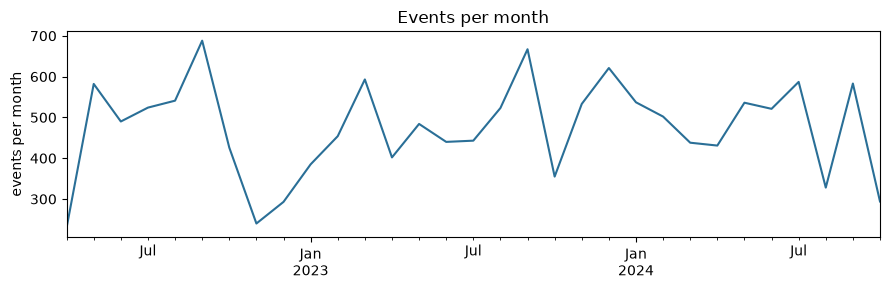

In [24]:
# ข้อมูลในช่วงท้ายของ log อาจถูกตัด (เคสยังไม่ถึงเวลาจ่าย)
last = xo.groupby('ocel_object_id').ocel_time.max()
R['events_last_30_days'] = int((ev.ocel_time > ev.ocel_time.max() - pd.Timedelta(days=30)).sum())
monthly = ev.set_index('ocel_time').resample('MS').size()
R['events_per_month_min'] = int(monthly.min()); R['events_per_month_max'] = int(monthly.max())
fig, ax = plt.subplots(figsize=(9,3))
monthly.plot(ax=ax, color='#2a6f97'); ax.set_ylabel('events per month'); ax.set_xlabel('')
ax.set_title('Events per month'); fig.tight_layout(); fig.savefig(FIG/'01_events_per_month.png', dpi=150)
monthly.describe().round(1)

### 5.7 attribute ของ object: ค่าเริ่มต้น vs. การเปลี่ยนแปลง
ตาราง `object_*` เก็บค่าเริ่มต้น (timestamp 1970-01-01) และแถวการเปลี่ยนแปลง (`ocel_changed_field`)

In [25]:
omap = pd.read_sql('select * from object_map_type', con)
rows = []
for _, r in omap.iterrows():
    a = d.load_object_attributes(con, r.ocel_type_map)
    init = a[a.ocel_time.dt.year==1970]; chg = a[a.ocel_time.dt.year!=1970]
    rows.append({'object_type': r.ocel_type, 'rows': len(a), 'initial_rows': len(init),
                 'change_rows': len(chg), 'objects_with_changes': chg.ocel_id.nunique(),
                 'change_time_min': chg.ocel_time.min(), 'change_time_max': chg.ocel_time.max()})
attr = pd.DataFrame(rows); R['object_attribute_rows'] = attr.astype(str).to_dict('records'); attr

,object_type,rows,initial_rows,change_rows,objects_with_changes,change_time_min,change_time_max
0,goods receipt,11966,1941,10025,1941,2022-04-11 08:52:00+00:00,2024-10-29 07:55:00+00:00
1,invoice receipt,8691,927,7764,927,2022-04-13 07:49:00+00:00,2024-10-29 08:10:00+00:00
2,material,2296,2296,0,0,NaT,NaT
3,payment,3259,927,2332,927,2022-04-16 15:46:00+00:00,2024-10-31 20:28:00+00:00
4,purchase_order,9588,1598,7990,1598,2022-04-06 07:45:00+00:00,2024-10-22 17:36:00+00:00
5,purchase_requisition,2583,927,1656,927,2022-04-02 14:16:00+00:00,2024-10-16 17:45:00+00:00
6,quotation,4635,927,3708,927,2022-04-05 16:09:00+00:00,2024-10-16 17:45:00+00:00


**ข้อสังเกต:** เวลาของแถวการเปลี่ยนแปลงอยู่ในช่วงเดียวกับ event จึงดูเป็นเวลาทางธุรกิจ ส่วนค่าเริ่มต้นใช้ 1970-01-01 เป็นค่าแทน "ไม่มีเวลา" ต้องตัดทิ้งก่อนวิเคราะห์เวลา

### 5.8 เวลาซ้ำใน invoice receipt เกิดจากอะไร
ดูว่า activity ไหนบ้างที่มี timestamp ตรงกันบน invoice เดียวกัน

In [26]:
ir = xo[xo.object_type=='invoice receipt']
grp = ir.groupby(['ocel_object_id','ocel_time'])
combo = grp.activity.apply(lambda s: ' + '.join(sorted(s)))[grp.size()>1]
R['invoice_tie_patterns'] = combo.value_counts().to_dict()
combo.value_counts()

activity
Perform Two-Way Match + Perform Two-Way Match                                                    193
Perform Two-Way Match + Perform Two-Way Match + Perform Two-Way Match                             45
Perform Two-Way Match + Perform Two-Way Match + Perform Two-Way Match + Perform Two-Way Match      4
Name: count, dtype: int64

ถ้าทั้งหมดเป็น `Perform Two-Way Match` ซ้ำ แปลว่าระบบจับคู่ invoice กับใบรับของหลายใบพร้อมกันในครั้งเดียว (1 ครั้งต่อ GR) เป็นลักษณะของการบันทึกแบบ batch ไม่ใช่ข้อผิดพลาด
ตอนทำ trace ให้รวมเป็นขั้นเดียว หรือเรียงด้วยรหัส event

### 5.9 รูปแบบ activity ของใบขอซื้อ (PR)
จำนวน `Create Purchase Requisition` (729) น้อยกว่าจำนวน PR object (927) ดูว่าแต่ละ PR มี activity อะไรบ้าง

In [27]:
pr_ev = xo[xo.object_type=='purchase_requisition']
pr_pat = pr_ev.groupby('ocel_object_id').activity.apply(lambda s: ' + '.join(sorted(set(s))))
R['pr_activity_patterns'] = pr_pat.value_counts().to_dict()
pr_pat.value_counts()

activity
Approve Purchase Requisition + Create Purchase Requisition + Create Request for Quotation              607
Create Request for Quotation                                                                           198
Create Purchase Requisition + Create Request for Quotation + Delegate Purchase Requisition Approval    122
Name: count, dtype: int64

**ข้อสันนิษฐาน (ยังไม่ใช่ข้อสรุป):**
- PR ที่มีแค่ `Create Request for Quotation` ไม่มีการสร้างหรืออนุมัติใบขอซื้อในระบบเลย อาจเป็นการจัดซื้อนอกขั้นตอน (maverick buying) ซึ่งคำอธิบายชุดข้อมูลบอกว่ามีการจำลองไว้
- PR ที่ถูก delegate แล้วไม่มี `Approve Purchase Requisition` ตามมา อาจแปลว่าการอนุมัติแทนไม่ถูกบันทึก หรือข้ามการอนุมัติไป
ทั้งสองเรื่องจะตรวจละเอียดในช่วง 4 (conformance)

## 7. ตัดสินใจ case notion
จากข้อ 3–4: สายเอกสารเป็นต้นไม้ที่มี PR เป็นราก เอกสารแต่ละใบมีพ่อตัวเดียว และไม่มีเอกสารที่ใช้ร่วมข้าม PR
จึงใช้ **1 เคส = 1 ใบขอซื้อ (PR) และเอกสารทั้งหมดที่ตามมา** เพื่อดูกระบวนการตั้งแต่ขอซื้อจนจ่ายเงิน
ข้อเสีย: เคสที่มีหลาย PO หรือหลาย GR จะมี activity ซ้ำใน trace (ไม่ใช่ rework จริง) ต้องแยกให้ออกตอนวิเคราะห์

In [28]:
# map ทุก object -> PR ต้นทาง
links = []
links.append(prs.assign(obj=prs.pr))
links.append(pr_q.rename(columns={'quotation':'obj'})[['pr','obj']])
pq = pr_q.merge(q_po);            links.append(pq.rename(columns={'po':'obj'})[['pr','obj']])
pg = pq.merge(po_gr);             links.append(pg.rename(columns={'gr':'obj'})[['pr','obj']])
pi = pg.merge(gr_ir);             links.append(pi.rename(columns={'ir':'obj'})[['pr','obj']])
pp = pi.merge(ir_pay);            links.append(pp.rename(columns={'payment':'obj'})[['pr','obj']])
pm = oo[(oo.source_type=='purchase_requisition')&(oo.target_type=='material')][['ocel_source_id','ocel_target_id']]
links.append(pm.rename(columns={'ocel_source_id':'pr','ocel_target_id':'obj'}))
obj2pr = pd.concat(links).drop_duplicates()
R['objects_mapped_to_pr'] = int(obj2pr.obj.nunique())
R['objects_mapped_to_multiple_prs'] = int((obj2pr.groupby('obj').pr.nunique()>1).sum())

ev2pr = eo.merge(obj2pr, left_on='ocel_object_id', right_on='obj')[['ocel_event_id','pr']].drop_duplicates()
per_event = ev2pr.groupby('ocel_event_id').pr.nunique()
R['events_mapped_to_a_case'] = int(per_event.size)
R['events_mapped_to_multiple_cases'] = int((per_event>1).sum())
R['events_not_mapped'] = int(len(ev) - per_event.size)
{k:R[k] for k in ['objects_mapped_to_pr','objects_mapped_to_multiple_prs','events_mapped_to_a_case','events_mapped_to_multiple_cases','events_not_mapped']}

{'objects_mapped_to_pr': 9543,
 'objects_mapped_to_multiple_prs': 0,
 'events_mapped_to_a_case': 14671,
 'events_mapped_to_multiple_cases': 0,
 'events_not_mapped': 0}

In [29]:
# event log แบบเคส: 1 แถว = 1 event ในเคส PR
flat = ev2pr.merge(ev, left_on='ocel_event_id', right_on='ocel_id')
flat = flat.rename(columns={'pr':'case:concept:name','activity':'concept:name',
                            'ocel_time':'time:timestamp','resource':'org:resource'})
flat = flat[['case:concept:name','ocel_event_id','concept:name','time:timestamp','org:resource']]
flat['_eid'] = flat.ocel_event_id.str.split(':').str[1].astype(int)
flat = flat.sort_values(['case:concept:name','time:timestamp','_eid']).drop(columns='_eid')
flat.to_csv(Path.cwd().parent/'data'/'p2p_cases_by_pr.csv', index=False)
per_case = flat.groupby('case:concept:name').size()
dur = flat.groupby('case:concept:name')['time:timestamp'].agg(lambda s:(s.max()-s.min()).total_seconds()/86400)
R['case_count'] = int(per_case.size)
R['events_per_case'] = per_case.describe().round(2).to_dict()
R['case_duration_days'] = dur.describe().round(1).to_dict()
pd.DataFrame({'events_per_case':per_case.describe(), 'duration_days':dur.describe()}).round(1)

,events_per_case,duration_days
count,927.0,927.0
mean,15.8,22.5
std,7.9,8.2
min,7.0,4.6
25%,9.0,16.7
50%,14.0,21.7
75%,20.0,27.0
max,38.0,66.0


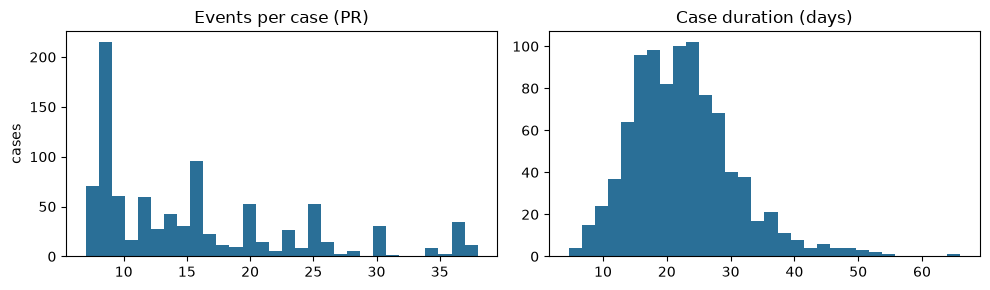

In [30]:
fig, ax = plt.subplots(1,2, figsize=(10,3))
per_case.plot.hist(bins=30, ax=ax[0], color='#2a6f97'); ax[0].set_title('Events per case (PR)'); ax[0].set_ylabel('cases')
dur.plot.hist(bins=30, ax=ax[1], color='#2a6f97'); ax[1].set_title('Case duration (days)'); ax[1].set_ylabel('')
fig.tight_layout(); fig.savefig(FIG/'01_case_size_duration.png', dpi=150)

## 8. สิ่งที่ต้องทำความสะอาด / ระวังในช่วงถัดไป
1. object type ต้องอ่านจากตาราง `object` ห้ามแยกจาก ID (ID ของ PR มี `:` เกินมา)
2. material ที่ไม่มี event ตัดทิ้งได้ (ไม่กระทบ trace)
3. ค่าเริ่มต้นของ attribute ใช้เวลา 1970-01-01 ต้องตัดออกก่อนวิเคราะห์เวลา
4. timestamp ละเอียดแค่ระดับนาที และมี `Perform Two-Way Match` หลายครั้งในเวลาเดียวกัน ต้องเรียงด้วยรหัส event เป็นตัวรอง
5. activity ซ้ำใน trace ส่วนใหญ่มาจากเคสที่มีหลาย PO / GR ต้องแยกจาก rework จริงตอนช่วง 5 (ใบรับของ 1 ใบที่มี `Create Goods Receipt` หลายครั้ง แต่ละครั้งอ้าง PO คนละใบ ดู 04)
6. `Execute Payment` มากกว่า 1 ครั้งต่อ payment ต้องตรวจในช่วง 4 ว่าเป็นการจ่ายซ้ำหรือจ่ายเป็นงวด

## 9. บันทึกตัวเลข

In [31]:
out = Path.cwd().parent / 'results' / '01_explore.json'
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str))
print('saved', out.relative_to(Path.cwd().parent), len(R), 'keys')

saved results/01_explore.json 52 keys
